In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
import os ,sys
sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess
from src.feature_engineering import create_features

In [6]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.head()
test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [4]:
train = preprocess(train)
train = create_features(train)

X = train.drop(columns=["health_condition"])
y = train["health_condition"]

print(X.shape)

(690088, 33)


In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
import json

with open("../output/models/best_params.json", "r") as f:
    best_params = json.load(f)

best_params

{'bootstrap_type': 'Bernoulli',
 'learning_rate': 0.03309416821002669,
 'depth': 7,
 'l2_leaf_reg': 10.801507310686478,
 'random_strength': 0.898531201248234,
 'border_count': 253,
 'grow_policy': 'Depthwise',
 'leaf_estimation_iterations': 9,
 'min_data_in_leaf': 25,
 'subsample': 0.6828948177465322,
 'iterations': 1200,
 'loss_function': 'MultiClass',
 'eval_metric': 'MultiClass',
 'task_type': 'GPU',
 'devices': '0',
 'random_seed': 42,
 'verbose': 200,
 'auto_class_weights': 'Balanced'}

In [10]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

model = CatBoostClassifier(**best_params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    verbose=100
)

0:	learn: 1.0004885	total: 86.9ms	remaining: 1m 44s
100:	learn: 0.1675229	total: 7.09s	remaining: 1m 17s
200:	learn: 0.1580657	total: 13.8s	remaining: 1m 8s
300:	learn: 0.1506231	total: 20.7s	remaining: 1m 1s
400:	learn: 0.1438171	total: 27.6s	remaining: 55s
500:	learn: 0.1375399	total: 34.5s	remaining: 48.1s
600:	learn: 0.1316701	total: 41.4s	remaining: 41.2s
700:	learn: 0.1265184	total: 47.9s	remaining: 34.1s
800:	learn: 0.1213763	total: 54.5s	remaining: 27.1s
900:	learn: 0.1165078	total: 1m 1s	remaining: 20.3s
1000:	learn: 0.1120753	total: 1m 7s	remaining: 13.4s
1100:	learn: 0.1077653	total: 1m 14s	remaining: 6.69s
1199:	learn: 0.1036208	total: 1m 21s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', bootstrap_type='Bernoulli', border_count=253, depth=7, devices='0', eval_metric='MultiClass', grow_policy='Depthwise', iterations=1200, l2_leaf_reg=10.801507310686478, leaf_estimation_iterations=9, learning_rate=0.03309416821002669, loss_function='MultiClass', min_data_in_leaf=25, random_seed=42, random_strength=0.898531201248234, subsample=0.6828948177465322, task_type='GPU', verbose=200)

In [11]:
# CatBoost Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
0,sleep_duration,41.781268
8,stress_level,22.161227
2,bmi,15.937197
10,physical_activity_level,6.641373
29,activity_diet,1.897836
31,smoking_stress,1.793429
30,gender_activity,0.921273
28,stress_sleep,0.853574
11,smoking_alcohol,0.822575
22,bmi_sleep,0.785641


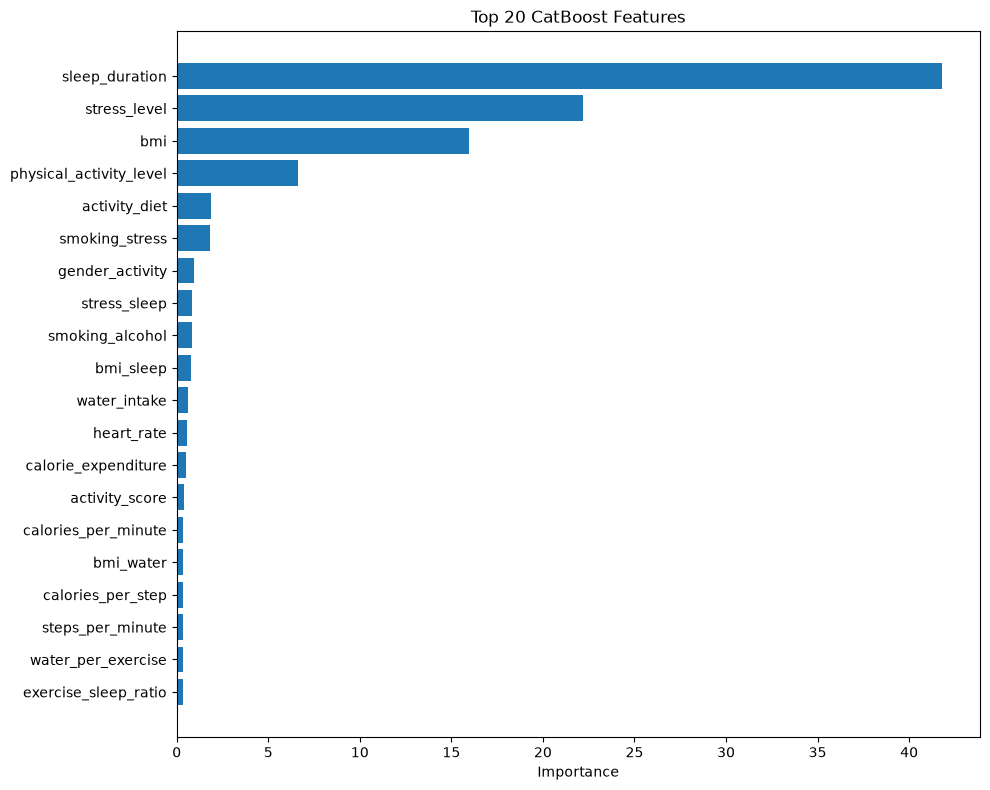

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.title("Top 20 CatBoost Features")
plt.xlabel("Importance")
plt.tight_layout()

plt.show()

In [13]:
selected_features = importance[
    importance["Importance"] > 0.5
]["Feature"]

len(selected_features)

12

In [14]:
X_train_small = X_train[selected_features]
X_valid_small = X_valid[selected_features]

X_train_small.shape

(552070, 12)

In [15]:
categorical_features = X_train_small.select_dtypes(
    include=["object", "category"]
).columns.tolist()

small_model = CatBoostClassifier(**best_params)

small_model.fit(
    X_train_small,
    y_train,
    cat_features=categorical_features,
    verbose=100
)

0:	learn: 0.9988237	total: 70.9ms	remaining: 1m 25s
100:	learn: 0.1714156	total: 6.51s	remaining: 1m 10s
200:	learn: 0.1626740	total: 13.1s	remaining: 1m 5s
300:	learn: 0.1559924	total: 19.5s	remaining: 58.3s
400:	learn: 0.1495459	total: 26s	remaining: 51.8s
500:	learn: 0.1438119	total: 32.6s	remaining: 45.5s
600:	learn: 0.1381232	total: 39.6s	remaining: 39.4s
700:	learn: 0.1331772	total: 46.6s	remaining: 33.2s
800:	learn: 0.1284256	total: 53.1s	remaining: 26.5s
900:	learn: 0.1238875	total: 59.7s	remaining: 19.8s
1000:	learn: 0.1197886	total: 1m 6s	remaining: 13.2s
1100:	learn: 0.1159475	total: 1m 13s	remaining: 6.58s
1199:	learn: 0.1118758	total: 1m 19s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', bootstrap_type='Bernoulli', border_count=253, depth=7, devices='0', eval_metric='MultiClass', grow_policy='Depthwise', iterations=1200, l2_leaf_reg=10.801507310686478, leaf_estimation_iterations=9, learning_rate=0.03309416821002669, loss_function='MultiClass', min_data_in_leaf=25, random_seed=42, random_strength=0.898531201248234, subsample=0.6828948177465322, task_type='GPU', verbose=200)

In [17]:
pred = small_model.predict(X_valid_small)

score = balanced_accuracy_score(
    y_valid,
    pred
)

print("Balanced Accuracy:", score)

Balanced Accuracy: 0.9473902907348825


In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Original CatBoost",
        "Reduced Features"
    ],
    "Balanced Accuracy": [
        0.94985,
        score
    ]
})

comparison

,Model,Balanced Accuracy
0,Original CatBoost,0.94985
1,Reduced Features,0.94739


# Conclusion

Feature selection was performed using CatBoost feature importance.

A reduced feature set was created by removing low-importance features and retraining the model.

| Model | Balanced Accuracy |
|--------|------------------:|
| Original CatBoost | 0.94985 |
| Reduced Features | 0.94739 |

The reduced model showed a slight decrease in Balanced Accuracy.

This indicates that several low-importance features still provide useful information through feature interactions. Therefore, the final production model retains all engineered features.